# Clasificación mediante Regresión Logística

## Objetivo

El objetivo de este trabajo es aplicar un modelo de Regresión Logística para predecir el sistema operativo utilizado por un usuario que visita un sitio web a partir de distintas características de su navegación.

Las variables de entrada son:

- **duracion:** duración de la visita en segundos.
- **paginas:** cantidad de páginas vistas durante la sesión.
- **acciones:** cantidad de acciones realizadas por el usuario.
- **valor:** suma del valor asignado a las acciones.

La variable que se desea predecir es:

- **clase:** sistema operativo utilizado por el usuario.
  - 0 = Windows
  - 1 = Macintosh
  - 2 = Linux

### Pregunta de análisis

**¿Es posible predecir qué sistema operativo utiliza un usuario a partir de las características de su navegación en el sitio web?**

In [1]:
import pandas as pd

df = pd.read_csv("data/usuarios_win_mac_lin.csv")

df.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


In [2]:
df.shape

(170, 5)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duracion  170 non-null    float64
 1   paginas   170 non-null    int64  
 2   acciones  170 non-null    int64  
 3   valor     170 non-null    int64  
 4   clase     170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB


In [4]:
df['clase'].value_counts()

clase
0    86
2    44
1    40
Name: count, dtype: int64

In [5]:
X = df[['duracion', 'paginas', 'acciones', 'valor']]
y = df['clase']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [7]:
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (136, 4)
Datos de prueba: (34, 4)


In [8]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(solver='lbfgs', max_iter=1000)

In [9]:
modelo.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [10]:
y_pred = modelo.predict(X_test)

In [11]:
y_pred

array([2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 0, 2, 0, 0, 2, 2, 2, 0, 2, 0, 0, 0,
       0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 1, 1])

In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Exactitud del modelo:", accuracy)

Exactitud del modelo: 0.7352941176470589


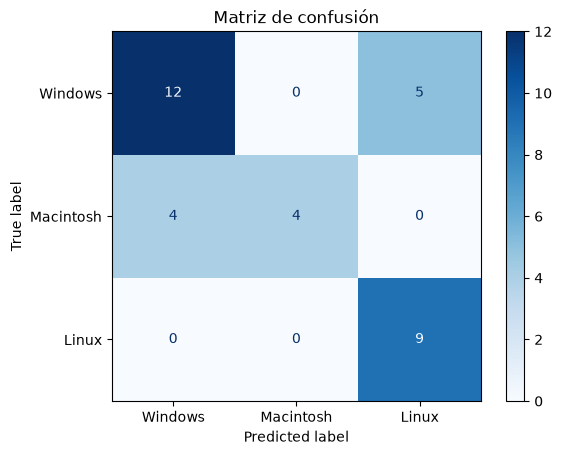

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Windows", "Macintosh", "Linux"],
    cmap="Blues"
)

plt.title("Matriz de confusión")
plt.show()

### Interpretación de la matriz de confusión

La matriz de confusión permite comparar las clases reales con las predicciones realizadas por el modelo. Los valores de la diagonal representan las predicciones correctas.

El modelo clasificó correctamente **12 de 17 usuarios de Windows**, **4 de 8 usuarios de Macintosh** y **9 de 9 usuarios de Linux**. Los principales errores se produjeron al clasificar usuarios de Windows como Linux y usuarios de Macintosh como Windows.

In [14]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Windows", "Macintosh", "Linux"]
))

              precision    recall  f1-score   support

     Windows       0.75      0.71      0.73        17
   Macintosh       1.00      0.50      0.67         8
       Linux       0.64      1.00      0.78         9

    accuracy                           0.74        34
   macro avg       0.80      0.74      0.73        34
weighted avg       0.78      0.74      0.73        34



In [15]:
resultados = pd.DataFrame({
    'Real': y_test.values,
    'Predicción': y_pred
})

nombres = {
    0: 'Windows',
    1: 'Macintosh',
    2: 'Linux'
}

resultados['Real'] = resultados['Real'].map(nombres)
resultados['Predicción'] = resultados['Predicción'].map(nombres)

resultados.head(10)

,Real,Predicción
0,Linux,Linux
1,Windows,Linux
2,Linux,Linux
3,Linux,Linux
4,Linux,Linux
5,Windows,Linux
6,Windows,Windows
7,Windows,Linux
8,Linux,Linux
9,Macintosh,Windows


## Conclusión

En esta actividad se aplicó un modelo de **Regresión Logística** para clasificar el sistema operativo utilizado por los usuarios a partir de sus datos de navegación. El modelo alcanzó una **exactitud del 73,53 %** en los datos de prueba.

La **matriz de confusión** y el *recall* permitieron observar diferencias entre las clases. El modelo identificó correctamente el **71 % de los usuarios de Windows**, el **50 % de los usuarios de Macintosh** y el **100 % de los usuarios de Linux**. Esto muestra que el modelo tuvo mayor dificultad para identificar los casos de Macintosh, mientras que logró reconocer todos los casos reales de Linux presentes en el conjunto de prueba.